# F03: BARRA-R2 850 hPa wind regimes

# Preamble

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.colors as mc
import matplotlib.patches as mpatches
import shapely
from shapely import geos
import netCDF4
import os
import geopandas
import seaborn as sns
import PIL
import metpy.calc as mpcalc
from metpy.units import units
import matplotlib.cm as cm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pyproj
import mpl_toolkits
from scipy.stats import circmean
import windrose
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [2]:
# Open and regrid ETOPO2V2 dataset
NOAA_ETOPO2V2_ds = xr.open_dataset('/home/563/ac9768/GBR/Aus_Bathymetry/ETOPO2v2c_f4.GQp62nWv.nc.part',engine="netcdf4")
NOAA_ETOPO2V2_ds_slice = NOAA_ETOPO2V2_ds.sel(x=slice(140,155),y=slice(-22,-11))
lon = np.linspace(min(NOAA_ETOPO2V2_ds_slice['x'].data), max(NOAA_ETOPO2V2_ds_slice['x'].data), len(NOAA_ETOPO2V2_ds_slice['x'].data))
lat = np.linspace(min(NOAA_ETOPO2V2_ds_slice['y'].data), max(NOAA_ETOPO2V2_ds_slice['y'].data), len(NOAA_ETOPO2V2_ds_slice['y'].data))
lon, lat = np.meshgrid(lon, lat)
topo = NOAA_ETOPO2V2_ds_slice['z'].data

# To plot:
1. Process BARRA-R2 data

In [6]:
import matplotlib as mpl
mpl.rcParams.update({
    'axes.titlesize': 20,        # Title font size
    'axes.labelsize': 15,        # Axis label font size
    'xtick.labelsize': 12,       # X-axis tick label font size
    'ytick.labelsize': 12,       # Y-axis tick label font size
    'legend.fontsize': 12,       # Legend font size
    'figure.titlesize': 20,      # Figure suptitle font size
})

In [7]:
barra_towns = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa-winds_towns.nc", engine="h5netcdf",chunks="auto").sel(time=slice('1979-01-01T00:00:00.000000000','2023-05-01T00:00:00.000000000'))
barra_cairns = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa-winds_cairns.nc", engine="h5netcdf",chunks="auto").sel(time=slice('1979-01-01T00:00:00.000000000','2023-05-01T00:00:00.000000000'))
barra_willis = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa-winds_willis.nc", engine="h5netcdf",chunks="auto").sel(time=slice('1979-01-01T00:00:00.000000000','2023-05-01T00:00:00.000000000'))

barra_sfc_towns = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_hourly-mean-sfc-winds_towns-radar-site.nc", engine="h5netcdf",chunks="auto").resample(time='1h').mean()
barra_sfc_cairns = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_hourly-mean-sfc-winds_cairns-radar-site.nc", engine="h5netcdf",chunks="auto").resample(time='1h').mean()
barra_sfc_willis = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_hourly-mean-sfc-winds_willis-radar-site.nc", engine="h5netcdf",chunks="auto").resample(time='1h').mean()


In [12]:
def utc_to_lst_shift(ds, longitude_center: float):
    """
    Shift xarray data from UTC to Local Solar Time by offsetting the 
    time coordinate. Adds the LST offset to time labels directly —
    does NOT roll/wrap data values.

    Args:
        ds:               xarray Dataset or DataArray with a 'time' dimension.
        longitude_center: Representative longitude of the region (decimal degrees).

    Returns:
        Dataset/DataArray with time coordinate relabelled to LST.
    """
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    ds_lst = ds.assign_coords(time=ds.time + offset)
    return ds_lst

In [16]:
#for wind bar charts (b,c,d)
import string
def plot_regime_stats(all_values,ax,title,fig,label_start=0,legend: bool=False):
    """_summary_

    Args:
        all_values (_type_): _description_
        ax (_type_): _description_
        title (_type_): _description_
        legend (bool, optional): _description_. Defaults to False.
    """
    # Unpack the directional values
    categories = ["Jan", "Feb", "Mar", "Apr"]
    values1, values2, values3, values4 = zip(*all_values)

    # Plotting
    sns.set_theme(style="dark")
    ax.bar(categories, values1, label='NE', color='#FFB000')#'seagreen')
    ax.bar(categories, values2, bottom=values1, label='SE', color='#648FFF')#'royalblue')
    bottom2 = [i + j for i, j in zip(values1, values2)]
    ax.bar(categories, values3, bottom=bottom2, label='SW', color='#785EF0')#'purple')
    bottom3 = [i + j for i, j in zip(bottom2, values3)]
    ax.bar(categories, values4, bottom=bottom3, label='NW', color='#FE6100')#'darkorange')
    labels = list(string.ascii_lowercase)
    
    # Add text labels
    for i, (v1, v2, v3, v4) in enumerate(zip(values1, values2, values3, values4)):
        ax.text(i, v1 - v1 / 2 - 2, f'{v1:.1f}', ha='center', va='bottom', color="black", fontsize=10)
        ax.text(i, v1 + v2 / 2, f'{v2:.1f}', ha='center', va='bottom', color="black",fontsize=10)
        ax.text(i, v1 + v2 + v3 / 2 - 2, f'{v3:.1f}', ha='center', va='bottom', color="black",fontsize=10)
        ax.text(i, v1 + v2 + v3 + v4 / 2 - 2, f'{v4:.1f}', ha='center', va='bottom', color="black",fontsize=10)
    subplot_label = labels[label_start+1]
    ax.text(
        0.00, 1.02,
        f'({subplot_label})',
        transform=ax.transAxes,
        fontsize=18,
        va='bottom', ha='left'
    )
    ax.set_ylim(0, 100)
    ax.set_yticklabels([])
    ax.set_ylabel('Frequency (%)')
    ax.set_title(title, 
                 # pad=10,
                 fontsize=20)
    
    if legend:
        legend_elements = [
            # NE
            Patch(facecolor='#FFB000',#'green',
                  alpha=1,
                  label='NE'),
            # SE
            Patch(facecolor='#648FFF',#'blue', 
                  alpha=1,
                  label='SE'),
            # SW
            Patch(facecolor='#785EF0',#'purple', 
                  alpha=1,
                  label='SW'),
            # NW
            Patch(facecolor='#FE6100',#'orange', 
                  alpha=1,
                  label='NW'),
        ]
        fig.legend(
            handles=legend_elements,
            loc='lower center',
            ncol=4,
            frameon=True,
            bbox_to_anchor=(0.768, 0.03),
            fontsize=14,
        )
    return

def get_data(barra_ds, longitude_center):
    ds = barra_ds
    
    # 1. Shift to LST
    ds_lst = utc_to_lst_shift(ds, longitude_center)
    winds = ds_lst["wind_dir"].compute()
    
    # 2. Extract noon LST for classification
    winds_noon = winds.sel(time=winds.time.dt.hour == 12)
    
    # 3. Group noon winds by month
    months = winds_noon.groupby(winds_noon.time.dt.month)
    
    def wind_counts(noon_winds):
        """Classify days by noon LST direction, count days per regime."""
        noon_winds = noon_winds.load()
        total_days = len(noon_winds)  # each entry = one day at noon
        
        bins = [(0, 90), (90, 180), (180, 270), (270, 360)]
        return [
            (noon_winds[(noon_winds > low) & (noon_winds <= high)].count() / total_days * 100)
            for low, high in bins
        ]
    
    selected_months = [1, 2, 3, 4]
    all_values = [wind_counts(months[m]) for m in selected_months]
    return all_values
    
# def get_data(barra_ds):
#     # Group wind directions by month
#     ds = barra_ds
#     months = ds["wind_dir"].groupby(ds["wind_dir"].time.dt.month)

#     # Function to compute directional frequencies
#     def wind_counts(winds):
#         winds = winds.load()
#         total = len(winds)
#         bins = [(0, 90), (90, 180), (180, 270), (270, 360)]
#         return [(winds[(winds > low ) & (winds <= high )].count() / total * 100)
#                 for low, high in bins]

#     # Process selected months
#     selected_months = [1, 2, 3, 4]  
#     all_values = [wind_counts(months[m]) for m in selected_months]
#     return all_values

In [21]:
def wind_times(barra_regime_ds: xr.Dataset, longitude_center: float):
    """
    Classify wind direction at LST solar noon (hour=12), then assign
    all hours of that day to the same wind regime.

    Args:
        barra_regime_ds:  xarray Dataset with 'wind_dir' and 'time' dimension.
        longitude_center: Representative longitude for LST conversion.

    Returns:
        ne, se, sw, nw: arrays of datetime64 timestamps (all hours) 
                        belonging to each wind regime day.
    """
    # 1. Shift full dataset to LST
    ds_lst = utc_to_lst_shift(barra_regime_ds, longitude_center)

    # 2. Extract wind_dir and compute (needed for boolean indexing)
    winds = ds_lst.wind_dir.compute()

    # 3. Select only solar noon (LST hour=12) for regime classification
    winds_noon = winds.sel(time=winds.time.dt.hour == 12)

    # 4. Classify noon wind direction → get dates (not full timestamps)
    ne_dates = winds_noon.time.values[(winds_noon.values >= 0)   & (winds_noon.values <= 90)]
    se_dates = winds_noon.time.values[(winds_noon.values > 90)   & (winds_noon.values <= 180)]
    sw_dates = winds_noon.time.values[(winds_noon.values > 180)  & (winds_noon.values <= 270)]
    nw_dates = winds_noon.time.values[(winds_noon.values > 270)  & (winds_noon.values <= 360)]

    # 5. Convert noon timestamps → date-only for day matching
    def noon_to_all_hours(regime_noon_times):
        """Given noon timestamps, return all LST timestamps on those days."""
        regime_dates = set(
            pd.Timestamp(t).date() for t in regime_noon_times
        )
        all_times = pd.DatetimeIndex(winds.time.values)
        mask = all_times.normalize().map(lambda d: d.date() in regime_dates)
        return winds.time.values[mask]

    ne_lst = noon_to_all_hours(ne_dates)
    se_lst = noon_to_all_hours(se_dates)
    sw_lst = noon_to_all_hours(sw_dates)
    nw_lst = noon_to_all_hours(nw_dates)

    # 6. Convert LST timestamps back to UTC by subtracting the offset
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    # ds_lst = ds.assign_coords(time=ds.time + offset)

    
    # offset_hours = round(longitude_center * 4 / 60)
    # offset = np.timedelta64(offset_hours, 'h')

    ne = ne_lst - offset
    se = se_lst - offset
    sw = sw_lst - offset
    nw = nw_lst - offset

    return ne, se, sw, nw

ne_towns,  se_towns,  sw_towns,  nw_towns  = wind_times(barra_towns,  lon_towns)
ne_cairns, se_cairns, sw_cairns, nw_cairns = wind_times(barra_cairns, lon_cairns)
ne_willis, se_willis, sw_willis, nw_willis = wind_times(barra_willis, lon_willis)

In [23]:
barra_towns.sel(time=ne_towns,method='nearest')

<xarray.Dataset> Size: 725kB
Dimensions:     (time: 30206)
Coordinates:
  * time        (time) datetime64[ns] 242kB 1979-01-11T14:00:00 ... 2023-04-3...
Data variables:
    wind_dir    (time) float64 242kB dask.array<chunksize=(30206,), meta=np.ndarray>
    wind_speed  (time) float64 242kB dask.array<chunksize=(30206,), meta=np.ndarray>
Attributes:
    note:     JFMA 850 hPa winds for the townsville radar domain, created wit...

/jobfs/169801703.gadi-pbs/ipykernel_1811671/4005793297.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


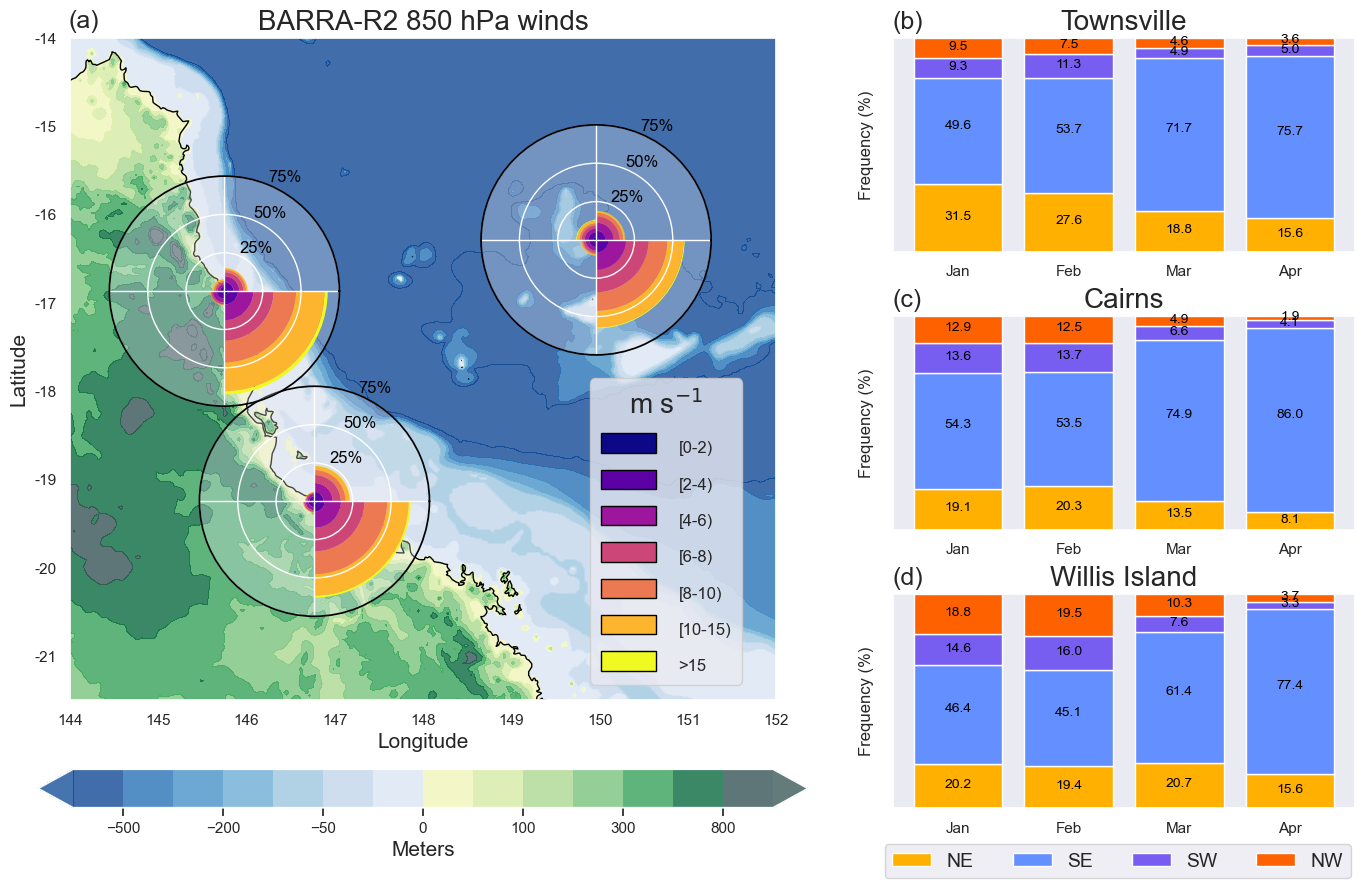

In [24]:
# all plots in one figure
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

fig = plt.figure(figsize=(18, 10))  # wider figure
gs = GridSpec(1, 2, width_ratios=[2, 1],wspace=0.01, figure=fig)  # left:map, right:3 subplots
sns.set_theme(style="dark")
# --- Left column: map ---
towns = barra_towns
cairns = barra_cairns
willis = barra_willis

proj = ccrs.PlateCarree()
main_ax = fig.add_subplot(gs[0, 0], projection=proj)
main_ax.set_extent([144, 152, -21.5, -14], crs=proj)
main_ax.coastlines()

color = ['#084594', '#2171b5', '#4292c6', '#6baed6', '#9ecae1', '#c6dbef', '#deebf7', '#f7fcb9','#d9f0a3','#addd8e',
         '#78c679','#31a354','#006837','darkslategrey','#d7ccca']
levels = [-800, -500, -300, -200, -100, -50, -25, 0, 50, 100, 200, 300, 500, 800, 1000]
cs = main_ax.contourf(lon,lat,topo,levels=levels,extend="both",colors=color,alpha=0.75)
cb = plt.colorbar(cs,fraction=0.05,location='bottom',orientation='horizontal',ax=main_ax,pad=0.09)
# cb = plt.colorbar(cs,aspect=20,ax=main_ax,pad=0.04)

# Coordinates of the station we were measuring windspeed
towns_lon, towns_lat = (146.77,-19.25)
cairns_lon, cairns_lat = (145.75,-16.87)
willis_lon, willis_lat = (149.96,-16.29)

size = 2.3
# Inset axes with a fixed size
sns.set_theme(style="dark")
wrax_towns = inset_axes(
    main_ax,
    width=size,  # size in inches
    height=size,  # size in inches
    loc="center",  # center bbox at given position
    bbox_to_anchor=(towns_lon, towns_lat),  # position of the axe
    bbox_transform=main_ax.transData,  # use data coordinate (not axe coordinate)
    axes_class=windrose.WindroseAxes,  # specify the class of the axe
)
wrax_cairns = inset_axes(
    main_ax,
    width=size,  # size in inches
    height=size,  # size in inches
    loc="center",  # center bbox at given position
    bbox_to_anchor=(cairns_lon, cairns_lat),  # position of the axe
    bbox_transform=main_ax.transData,  # use data coordinate (not axe coordinate)
    axes_class=windrose.WindroseAxes,  # specify the class of the axe
)
wrax_willis = inset_axes(
    main_ax,
    width=size,  # size in inches
    height=size,  # size in inches
    loc="center",  # center bbox at given position
    bbox_to_anchor=(willis_lon, willis_lat),  # position of the axe
    bbox_transform=main_ax.transData,  # use data coordinate (not axe coordinate)
    axes_class=windrose.WindroseAxes,  # specify the class of the axe
)

# # create windroses
def get_regime_winds_override(barra_ds, ne, se, sw, nw):
    """
    Return wind directions OVERRIDDEN to regime centre, with actual speeds.
    Regime centres: NE=45, SE=135, SW=225, NW=315
    """
    records = []
    for times, centre in [(ne, 45), (se, 135), (sw, 225), (nw, 315)]:
        if len(times) == 0:
            continue
        ds = barra_ds.sel(time=times)
        spd = ds["wind_speed"].values
        dir_override = np.full(len(spd), centre)  # override direction
        records.append((dir_override, spd))
    
    all_dirs = np.concatenate([r[0] for r in records])
    all_spds = np.concatenate([r[1] for r in records])
    return all_dirs, all_spds

towns_dir,  towns_spd  = get_regime_winds_override(barra_towns,  ne_towns,  se_towns,  sw_towns,  nw_towns)
cairns_dir, cairns_spd = get_regime_winds_override(barra_cairns, ne_cairns, se_cairns, sw_cairns, nw_cairns)
willis_dir, willis_spd = get_regime_winds_override(barra_willis, ne_willis, se_willis, sw_willis, nw_willis)

barT = wrax_towns.bar(towns_dir,  towns_spd,  normed=True, bins=[0,2,4,6,8,10,15],
                      opening=1, nsector=4, sectoroffset=45, cmap=cm.plasma)
barC = wrax_cairns.bar(cairns_dir, cairns_spd, normed=True, bins=[0,2,4,6,8,10,15],
                       opening=1, nsector=4, sectoroffset=45, cmap=cm.plasma)
barW = wrax_willis.bar(willis_dir, willis_spd, normed=True, bins=[0,2,4,6,8,10,15],
                       opening=1, nsector=4, sectoroffset=45, cmap=cm.plasma)

# barT = wrax_towns.bar(towns["wind_dir"], towns["wind_speed"],normed=True,bins=[0,2,4,6,8,10,15],opening=1,nsector=4,sectoroffset=45,cmap=cm.plasma)
# barC = wrax_cairns.bar(cairns["wind_dir"], cairns["wind_speed"],normed=True,bins=[0,2,4,6,8,10,15],opening=1,nsector=4,sectoroffset=45,cmap=cm.plasma)
# barW = wrax_willis.bar(willis["wind_dir"], willis["wind_speed"],normed=True,bins=[0,2,4,6,8,10,15],opening=1,nsector=4,sectoroffset=45,cmap=cm.plasma)
for ax, ec in zip([wrax_towns, wrax_cairns, wrax_willis], ['none', 'none', 'none']):
    for bar in ax.patches:
        bar.set_edgecolor(ec)
    
wrax_cairns.set_legend(
    title=r"m s$^{-1}$",
    bbox_to_anchor=(2.1, -1.2),
    fontsize=20,
    title_fontsize=20,
)
legend = wrax_cairns.get_legend()
for text, label in zip(legend.get_texts(), ['[0-2)', '[2-4)', '[4-6)', '[6-8)', '[8-10)', '[10-15)','>15']):
    text.set_text(label)
    text.set_fontsize(12)

for ax in [wrax_towns, wrax_cairns,wrax_willis]:
    ax.patch.set_alpha(0.3)
    ax.tick_params(colors='black',labelbottom=False)#labelleft=False
    ax.set_rmax(75)
    ax.spines['polar'].set_color('black')
    ax.set_yticks([25, 50, 75])
    ax.set_yticklabels(['25%', '50%', '75%'], fontsize=12)
    ax.set_thetagrids([0, 90, 180, 270])

sns.set_theme(style="dark")
# other plot details
cb.set_label("Meters",fontsize=15)
main_ax.set_title("BARRA-R2 850 hPa winds",fontsize=20,)#y=1.05)
# main_ax.set_title("BARRA-R2 surface winds 14 AEST",fontsize=18)
main_ax.set_xticks([144,145,146,147,148,149,150,151,152])
main_ax.set_xticklabels([144,145,146,147,148,149,150,151,152])
main_ax.set_yticks([-21,-20,-19,-18,-17,-16,-15,-14])
main_ax.set_yticklabels([-21,-20,-19,-18,-17,-16,-15,-14])
main_ax.set_xlabel("Longitude",fontsize=15)
main_ax.set_ylabel("Latitude",fontsize=15)
fig.text(
    0.185, 0.89,  # above bottom block
    "(a)",
    fontsize=18,
)

# --- Right column: 3 vertical subplots ---
# Create a nested GridSpec inside the right column
gs_right = GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[0, 1], hspace=0.3)

ax_col = [fig.add_subplot(gs_right[i]) for i in range(3)]

# Now plot your regime stats
# towns = get_data(barra_towns)
# cairns = get_data(barra_cairns)
# willis = get_data(barra_willis)
towns  = get_data(barra_towns,  lon_towns)  
cairns = get_data(barra_cairns, lon_cairns)
willis = get_data(barra_willis, lon_willis)

plot_regime_stats(towns, ax_col[0], "Townsville", fig, label_start=0,)
plot_regime_stats(cairns, ax_col[1], "Cairns", fig, label_start=1)
plot_regime_stats(willis, ax_col[2], "Willis Island", fig, label_start=2,legend=True)

plt.tight_layout()
plt.show()
fig.savefig('/home/563/ac9768/GBR/scripts/Chapman_etal_2026preprint/f03v4.png', bbox_inches='tight', dpi=300)